# ***Importing Libraries***

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# ***Exploratory Data Analysis (EDA)***

In [ ]:
df = pd.read_csv('train.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [ ]:
df.shape

(614, 13)

In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
df.drop("Loan_ID",axis=1,inplace=True)

In [ ]:
df.dtypes

,0
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
df.describe(include="object")

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,601,611,599,614,582,614,614
unique,2,2,4,2,2,3,2
top,Male,Yes,0,Graduate,No,Semiurban,Y
freq,489,398,345,480,500,233,422


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()/df.shape[0]*100

,0
Gender,2.117264
Married,0.488599
Dependents,2.442997
Education,0.000000
Self_Employed,5.211726
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,3.583062
Loan_Amount_Term,2.280130
Credit_History,8.143322


In [ ]:
(df==0).sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,273
LoanAmount,0
Loan_Amount_Term,0
Credit_History,89


In [ ]:
df.select_dtypes(include="object").nunique()

,0
Gender,2
Married,2
Dependents,4
Education,2
Self_Employed,2
Property_Area,3
Loan_Status,2


In [ ]:
df.select_dtypes(include="number").corr()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.570909,-0.045306,-0.014715
CoapplicantIncome,-0.116605,1.000000,0.188619,-0.059878,-0.002056
LoanAmount,0.570909,0.188619,1.000000,0.039447,-0.008433
Loan_Amount_Term,-0.045306,-0.059878,0.039447,1.000000,0.001470
Credit_History,-0.014715,-0.002056,-0.008433,0.001470,1.000000


In [ ]:
df.select_dtypes(include="number").cov()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,3.732039e+07,-2.084490e+06,301192.495450,-18207.365609,-33.671724
CoapplicantIncome,-2.084490e+06,8.562930e+06,47909.140428,-11503.765339,-1.854510
LoanAmount,3.011925e+05,4.790914e+04,7325.190241,222.894173,-0.255510
Loan_Amount_Term,-1.820737e+04,-1.150377e+04,222.894173,4240.667780,0.034019
Credit_History,-3.367172e+01,-1.854510e+00,-0.255510,0.034019,0.133136


In [ ]:
df.select_dtypes(include="number").skew()

,0
ApplicantIncome,6.539513
CoapplicantIncome,7.491531
LoanAmount,2.677552
Loan_Amount_Term,-2.362414
Credit_History,-1.882361


In [ ]:
df.select_dtypes(include="number").quantile([0.25,0.50,0.75,0.90,0.99])

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0.25,2877.50,0.00,100.00,360.0,1.0
0.50,3812.50,1188.50,128.00,360.0,1.0
0.75,5795.00,2297.25,168.00,360.0,1.0
0.90,9459.90,3782.20,235.80,360.0,1.0
0.99,32540.41,8895.89,496.36,480.0,1.0


In [ ]:
df.groupby("Gender")[["Loan_Amount_Term","Credit_History","CoapplicantIncome","ApplicantIncome"]].agg([np.mean,np.median,np.max,np.min])

Loan_Amount_Term                     Credit_History                   \
                   mean median    max   min           mean median  max  min   
Gender                                                                        
Female       352.293578  360.0  480.0  36.0       0.831683    1.0  1.0  0.0   
Male         339.665272  360.0  480.0  12.0       0.847007    1.0  1.0  0.0   

       CoapplicantIncome                       ApplicantIncome                 \
                    mean  median      max  min            mean  median    max   
Gender                                                                          
Female       1108.008929     0.0  41667.0  0.0     4643.473214  3583.0  19484   
Male         1742.932352  1430.0  33837.0  0.0     5446.460123  3865.0  81000   

             
        min  
Gender       
Female  210  
Male    150

In [ ]:
df.groupby("Married")[["Loan_Amount_Term","Credit_History","CoapplicantIncome","ApplicantIncome"]].agg([np.mean,np.median,np.max,np.min])

Loan_Amount_Term                     Credit_History                   \
                    mean median    max   min           mean median  max  min   
Married                                                                        
No            351.115385  360.0  480.0  36.0       0.839196    1.0  1.0  0.0   
Yes           336.987147  360.0  480.0  12.0       0.842541    1.0  1.0  0.0   

        CoapplicantIncome                       ApplicantIncome          \
                     mean  median      max  min            mean  median   
Married                                                                   
No            1316.558685     0.0  41667.0  0.0     4970.384977  3750.0   
Yes           1794.632965  1625.0  20000.0  0.0     5629.173367  3854.5   

                     
           max  min  
Married              
No       37719  416  
Yes      81000  150

In [ ]:
df.groupby("Education")[["Loan_Amount_Term","Credit_History","CoapplicantIncome","ApplicantIncome"]].mean()

,Loan_Amount_Term,Credit_History,CoapplicantIncome,ApplicantIncome
Education,,,,
Graduate,344.669492,0.857788,1717.474833,5857.433333
Not Graduate,332.156250,0.785124,1276.544776,3777.283582


In [ ]:
df.groupby("Self_Employed")[["Loan_Amount_Term","Credit_History","CoapplicantIncome","ApplicantIncome"]].mean()

,Loan_Amount_Term,Credit_History,CoapplicantIncome,ApplicantIncome
Self_Employed,,,,
No,343.263804,0.835853,1580.989840,5049.748000
Yes,336.300000,0.840000,1501.341463,7380.817073


In [ ]:
df.groupby("Property_Area")[["Loan_Amount_Term","Credit_History","CoapplicantIncome","ApplicantIncome"]].mean()

,Loan_Amount_Term,Credit_History,CoapplicantIncome,ApplicantIncome
Property_Area,,,,
Rural,345.531429,0.830303,1645.536983,5554.083799
Semiurban,347.113043,0.861751,1520.133047,5292.261803
Urban,332.800000,0.829670,1716.350495,5398.247525


In [ ]:
df.groupby("Married")[["Loan_Amount_Term","Credit_History","CoapplicantIncome","ApplicantIncome"]].mean()

,Loan_Amount_Term,Credit_History,CoapplicantIncome,ApplicantIncome
Married,,,,
No,351.115385,0.839196,1316.558685,4970.384977
Yes,336.987147,0.842541,1794.632965,5629.173367


# ***Data Visualization***

In [ ]:
cat_df = df.select_dtypes(include="object")
num_df = df.select_dtypes(include="number")

<Axes: >

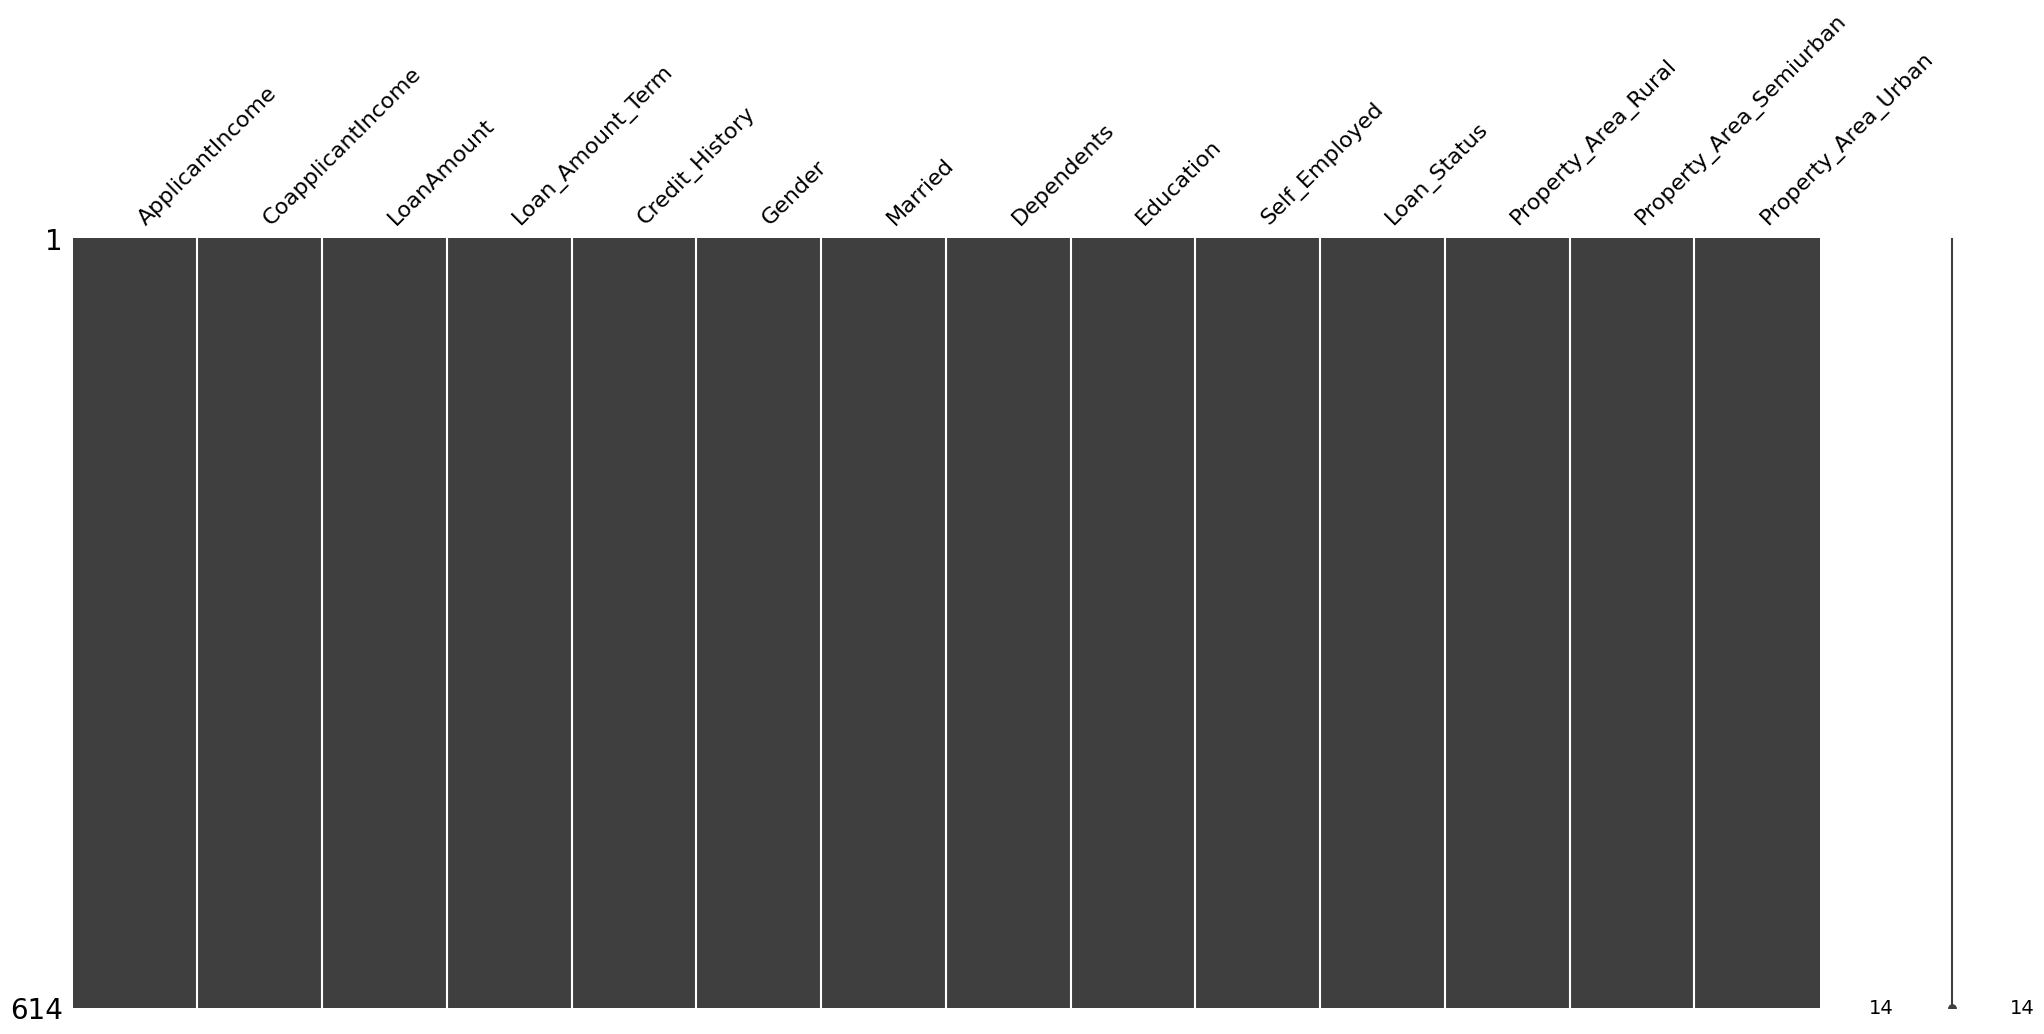

In [ ]:
import missingno as msno
msno.matrix(df)

<Axes: >

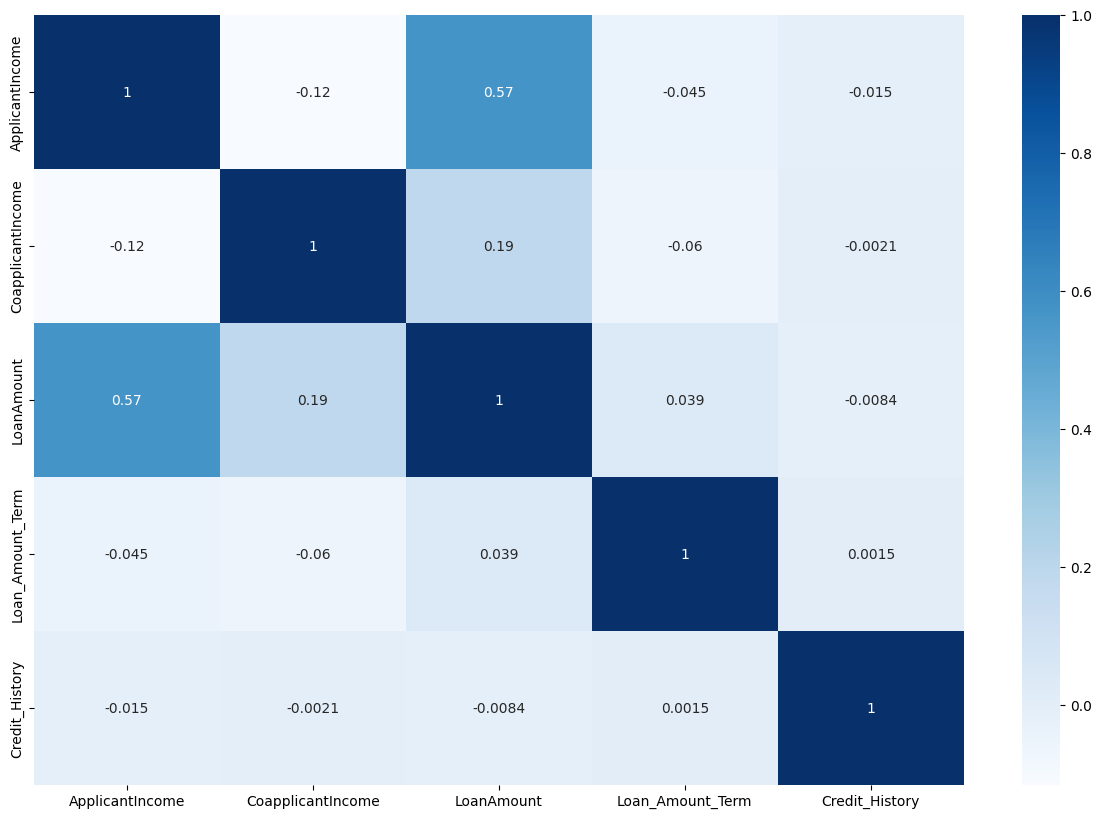

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(num_df.corr(), annot=True, cmap='Blues')

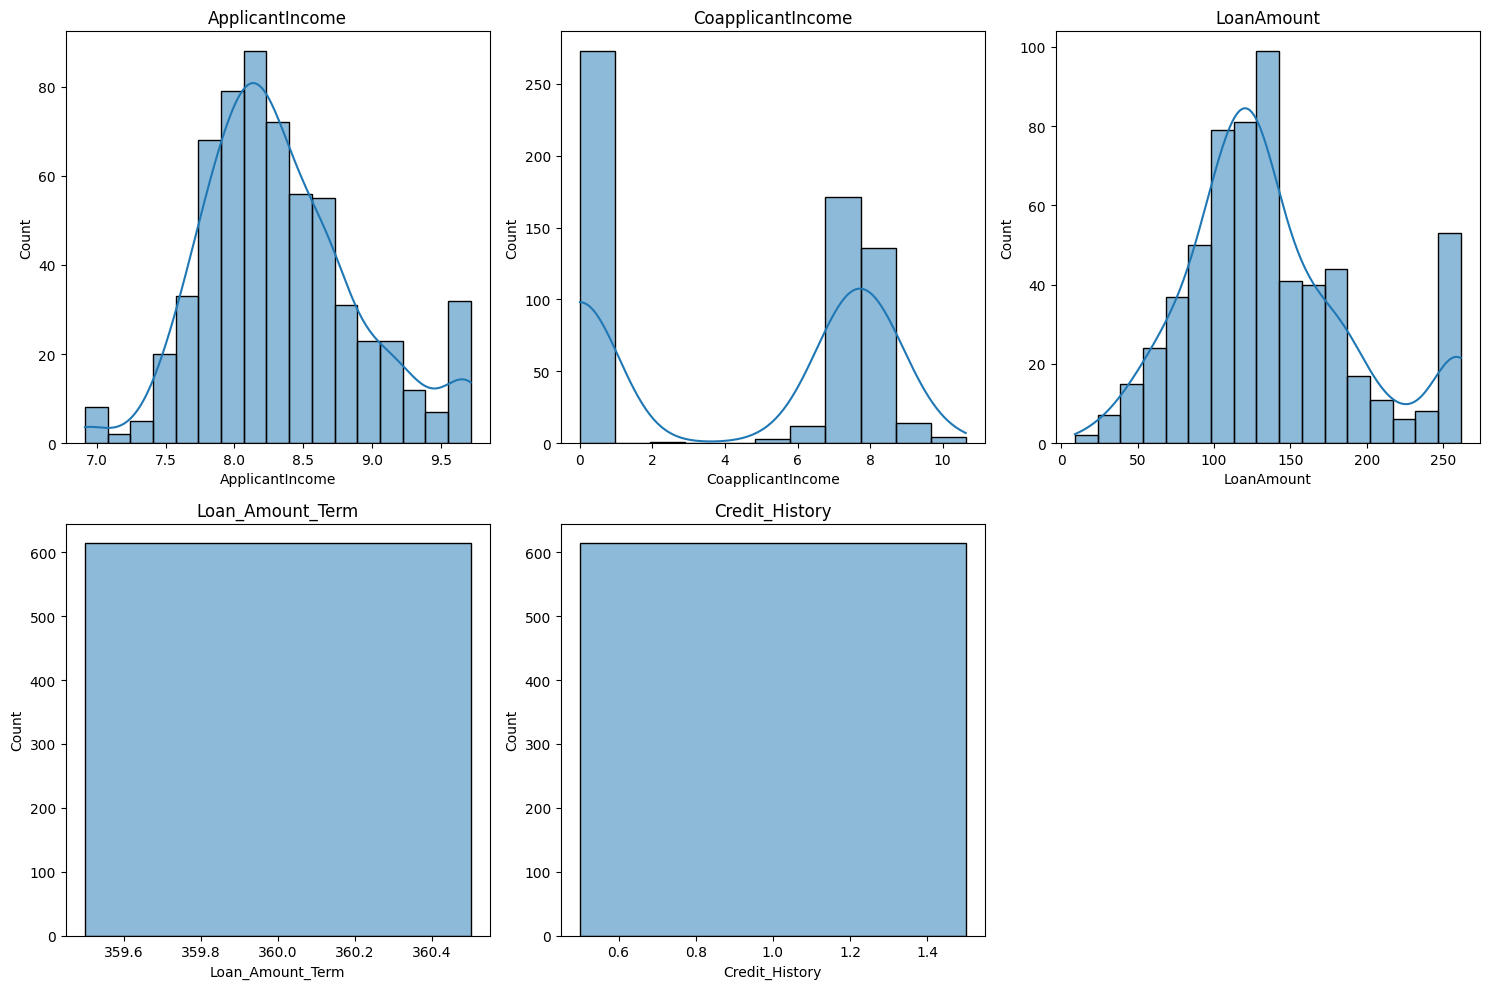

In [ ]:
cols = num_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(num_df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

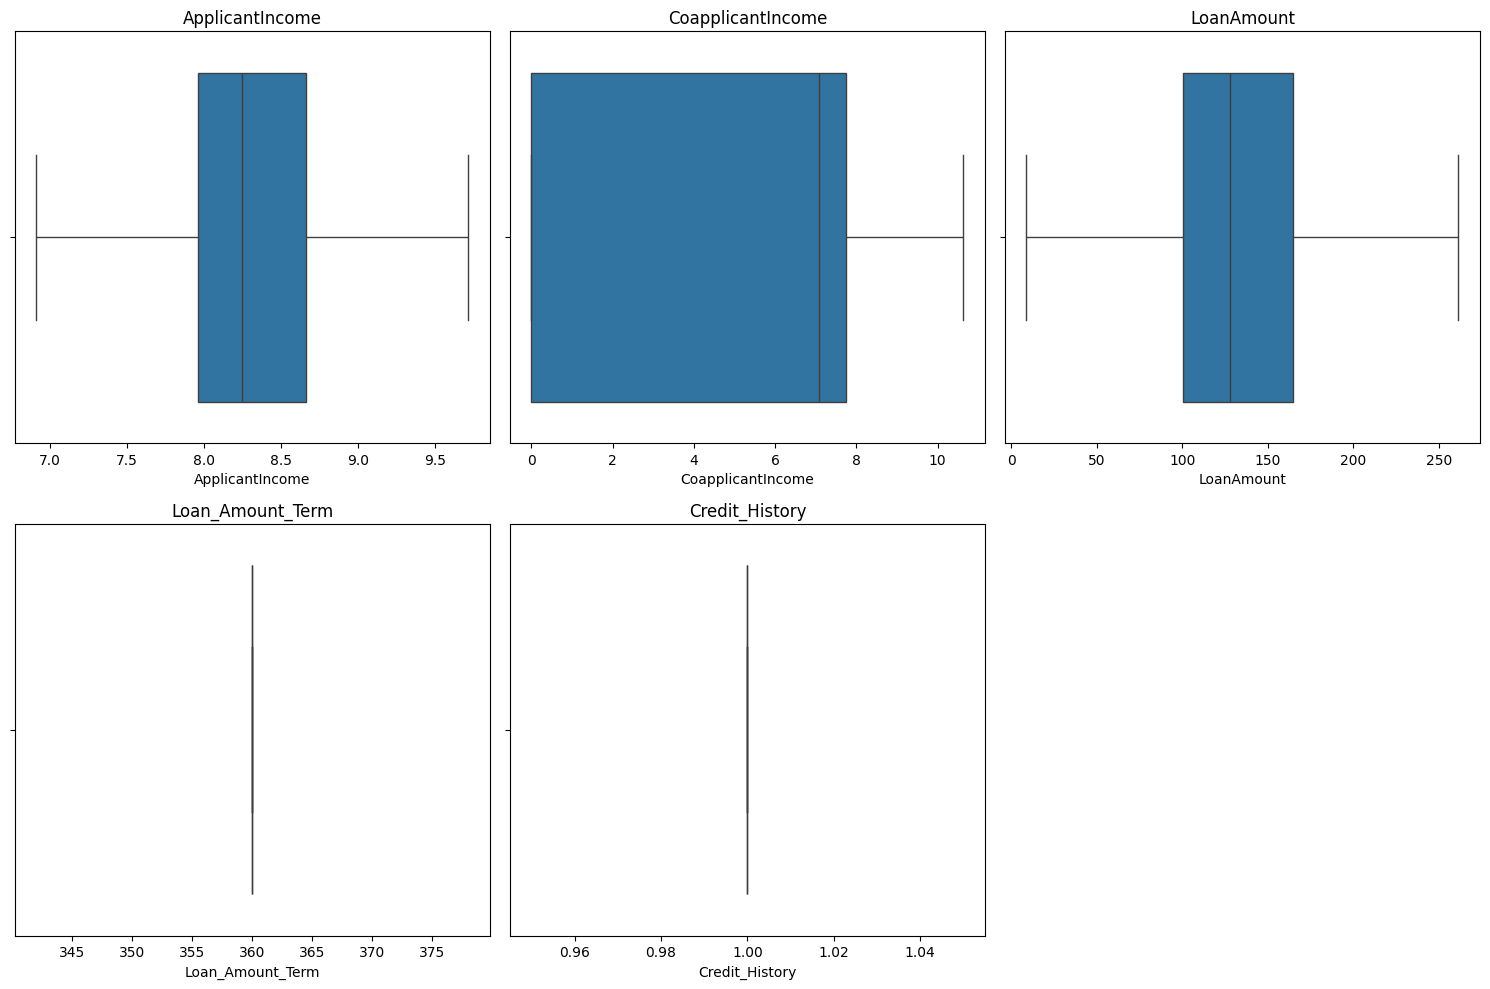

In [ ]:
cols = num_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=num_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

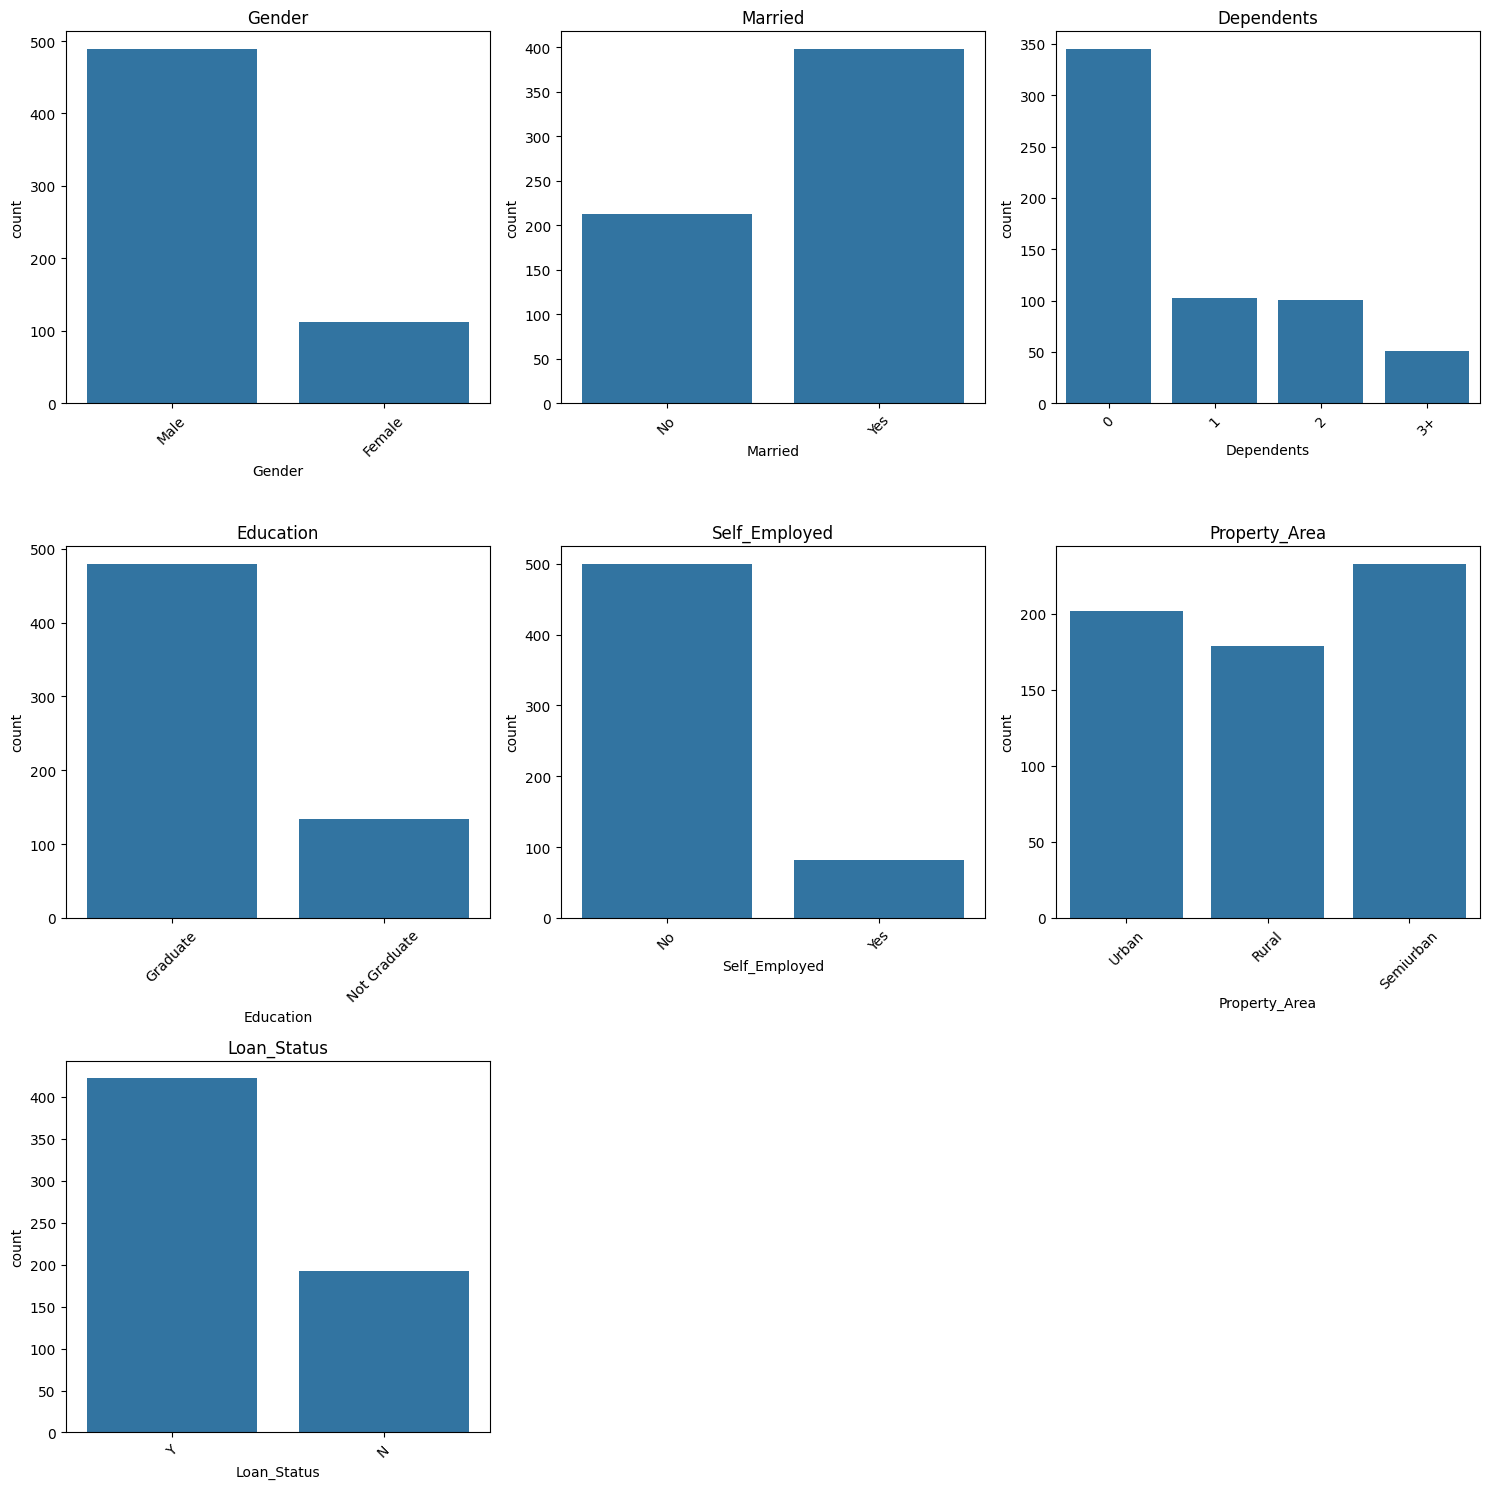

In [ ]:
cols = cat_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(x=cat_df[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Axes: xlabel='Loan_Status', ylabel='count'>

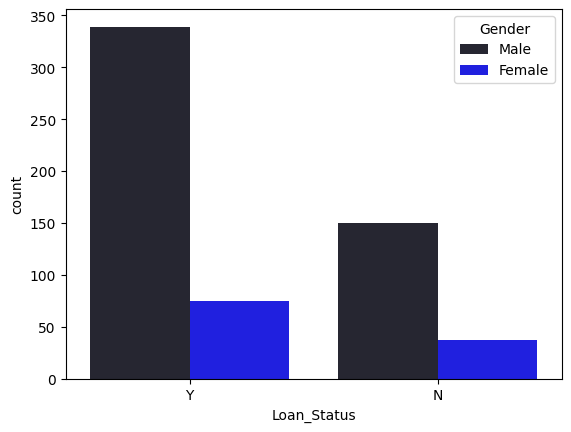

In [ ]:
sns.countplot(data=df, x='Loan_Status',hue='Gender', color="blue")

<Axes: xlabel='Loan_Status', ylabel='count'>

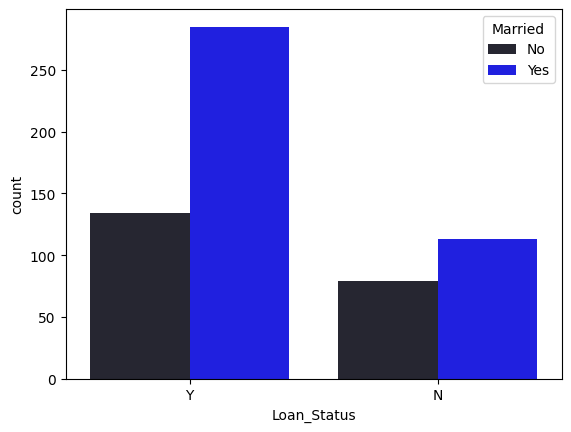

In [ ]:
sns.countplot(data=df, x='Loan_Status',hue='Married', color="blue")

<Axes: xlabel='Loan_Status', ylabel='count'>

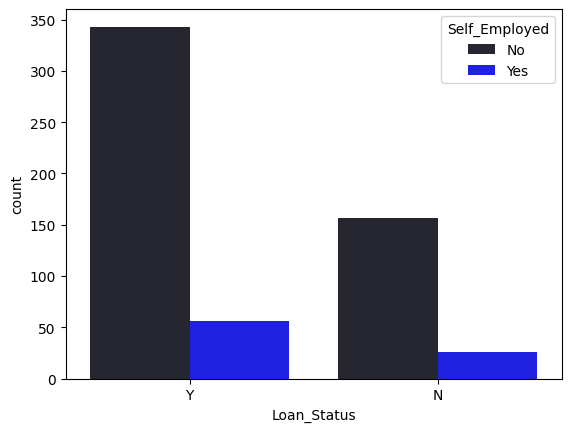

In [ ]:
sns.countplot(data=df, x='Loan_Status',hue='Self_Employed', color="blue")

<Axes: xlabel='Loan_Status', ylabel='count'>

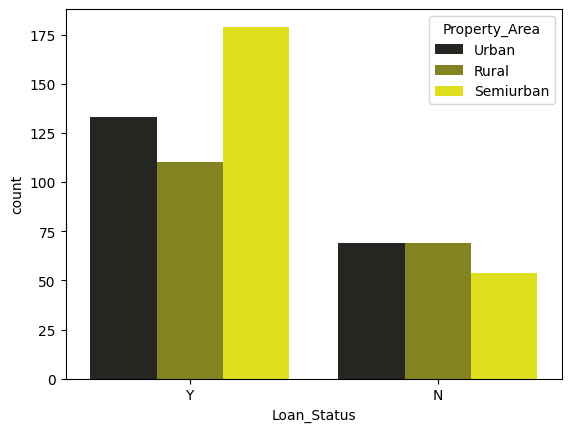

In [ ]:
sns.countplot(data=df, x='Loan_Status',hue='Property_Area', color="yellow")

# ***Data Preprocessing***

In [ ]:
cat_df['Gender'] = cat_df['Gender'].fillna(cat_df['Gender'].mode()[0])
cat_df['Married'] = cat_df['Married'].fillna(cat_df['Married'].mode()[0])
num_df['LoanAmount'] = num_df['LoanAmount'].fillna(num_df['LoanAmount'].median())
cat_df['Dependents'] = cat_df['Dependents'].fillna(cat_df['Dependents'].mode()[0])
cat_df['Self_Employed'] = cat_df['Self_Employed'].fillna(cat_df['Self_Employed'].mode()[0])
num_df['Credit_History'] = num_df['Credit_History'].fillna(num_df['Credit_History'].mode()[0])
num_df['Loan_Amount_Term'] = num_df['Loan_Amount_Term'].fillna(num_df['Loan_Amount_Term'].median())

In [ ]:
cat_df['Dependents'] = cat_df['Dependents'].replace('\+', '', regex=True).astype(int)

In [ ]:
num_df['ApplicantIncome'] = np.log1p(num_df['ApplicantIncome'])
num_df['CoapplicantIncome'] = np.log1p(num_df['CoapplicantIncome'])

In [ ]:
for col in num_df:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    num_df[col] = num_df[col].clip(lower, upper)


In [ ]:
cat_df

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,Urban,Y
1,Male,Yes,1,Graduate,No,Rural,N
2,Male,Yes,0,Graduate,Yes,Urban,Y
3,Male,Yes,0,Not Graduate,No,Urban,Y
4,Male,No,0,Graduate,No,Urban,Y
...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,Rural,Y
610,Male,Yes,3,Graduate,No,Rural,Y
611,Male,Yes,1,Graduate,No,Urban,Y
612,Male,Yes,2,Graduate,No,Urban,Y


In [ ]:
le = LabelEncoder()

binary_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Status']

for col in binary_cols:
    cat_df[col] = le.fit_transform(cat_df[col])

In [ ]:
cat_df = pd.get_dummies(cat_df, columns=['Property_Area'],dtype=int)

In [ ]:
df=pd.concat([num_df,cat_df],axis=1)

In [ ]:
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender,Married,Dependents,Education,Self_Employed,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,8.674197,0.000000,128.0,360.0,1.0,1,0,0,0,0,1,0,0,1
1,8.430327,7.319202,128.0,360.0,1.0,1,1,1,0,0,0,1,0,0
2,8.006701,0.000000,66.0,360.0,1.0,1,1,0,0,1,1,0,0,1
3,7.857094,7.765993,120.0,360.0,1.0,1,1,0,1,0,1,0,0,1
4,8.699681,0.000000,141.0,360.0,1.0,1,0,0,0,0,1,0,0,1


In [ ]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

print(y.value_counts())
print(y_resampled.value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64
Loan_Status
1    422
0    422
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

In [ ]:
models = {
    "KNN": (
        KNeighborsClassifier(),
        {
            'n_neighbors': [3,5,7,9],
            'weights': ['uniform','distance']
        }
    ),

    "LogisticRegression": (
        LogisticRegression(max_iter=1000,class_weight='balanced'),
        {
            'C': [0.01,0.1,1,10]
        }
    ),

    "DecisionTree": (
        DecisionTreeClassifier(class_weight='balanced'),
        {
            'max_depth': [None,5,10,20],
            'min_samples_split': [2,5,10]
        }
    ),

    "RandomForest": (
        RandomForestClassifier(class_weight='balanced'),
        {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5]
        }
    ),

    "GradientBoosting": (
        GradientBoostingClassifier(),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1]
        }
    ),

    "AdaBoost": (
        AdaBoostClassifier(),
        {
            'n_estimators': [50,100],
            'learning_rate': [0.01,0.1,1]
        }
    ),

    "ExtraTrees": (
        ExtraTreesClassifier(),
        {
            'n_estimators': [100,200],
            'max_depth': [None,10,20]
        }
    ),

    "SVM": (
        SVC(probability=True,class_weight='balanced'),
        {
            'C': [0.1,1,10],
            'kernel': ['rbf','linear']
        }
    ),

    "XGBoost": (
        XGBClassifier(eval_metric='logloss', use_label_encoder=False),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1],
            'max_depth': [3,6]
        }
    ),

    "LightGBM": (
        LGBMClassifier(),
        {
            'n_estimators': [100,200],
            'learning_rate': [0.01,0.1]
        }
    ),

    "CatBoost": (
        CatBoostClassifier(verbose=0),
        {
            'iterations': [100,200],
            'learning_rate': [0.01,0.1],
            'depth': [4,6]
        }
    )
}

In [ ]:
results = []

for name, (model, param_grid) in models.items():

    print(f"Training {name}...")

    grid = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    if hasattr(best_model, "predict_proba"):
        roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])
    else:
        roc_auc = np.nan

    cm = confusion_matrix(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "Confusion Matrix": cm
    })


Training KNN...
Training LogisticRegression...
Training DecisionTree...
Training RandomForest...
Training GradientBoosting...
Training AdaBoost...
Training ExtraTrees...
Training SVM...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Number of positive: 347, number of negative: 328
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000167 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 589
[LightGBM] [Info] Number of data points in the train set: 675, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.514074 -> initscore=0.056311
[LightGBM] [Info] Start training from score 0.056311
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="Recall", ascending=False).reset_index(drop=True)

print("\n===== Ranked by Recall =====")
print(results_df)

best_model_name = results_df.iloc[0]["Model"]
print(f"\n Best Model (Highest Recall): {best_model_name}")


===== Ranked by Recall =====
                 Model  Train Accuracy  Test Accuracy  Precision    Recall  \
0                  SVM        0.700741       0.656805   0.575221  0.866667   
1   LogisticRegression        0.702222       0.662722   0.583333  0.840000   
2             AdaBoost        0.721481       0.680473   0.606061  0.800000   
3     GradientBoosting        0.888889       0.644970   0.584270  0.693333   
4           ExtraTrees        0.998519       0.662722   0.609756  0.666667   
5              XGBoost        0.979259       0.668639   0.617284  0.666667   
6             CatBoost        0.992593       0.615385   0.556818  0.653333   
7         DecisionTree        0.742222       0.710059   0.685714  0.640000   
8         RandomForest        0.862222       0.668639   0.626667  0.626667   
9                  KNN        0.998519       0.692308   0.666667  0.613333   
10            LightGBM        0.985185       0.597633   0.543210  0.586667   

    F1 Score   ROC-AUC      Confu